## When to use DecisionTreeRegressor
- Non-linear and Complex Relationships: If your target variable changes in waves, steps, or has sudden threshold **jumps** relative to your features, decision trees handle this effortlessly without requiring you to manually transform the data.
- High Feature Interaction: When the impact of one feature depends heavily on another `if age > 30 and income < $50k`, trees naturally capture these combinations through sequential branching.
- Mixed Data Types & Minimal Preprocessing: They can handle both numerical and categorical data simultaneously. Furthermore, because trees look at splits rather than magnitudes, they are completely immune to feature scaling `you don’t need to normalize or standardize your data` and are **highly robust against outliers.**
- High Interpretability Requirements: If you need to explain exactly why a model made a specific prediction to stakeholders, you can easily trace the clear path of if-else logic down the tree.

$$Limitations of Decision Tree Regression$$

While Decision Tree Regression is highly flexible and excellent at capturing complex, non-linear patterns, it has structural flaws that make it a poor choice for certain scenarios. Below are the key situations where you should avoid using decision trees:

---

### 1. Extrapolation (Predicting Outside the Training Range)
Decision trees **cannot extrapolate**. Because the prediction is simply the average value of the training samples contained within a given leaf node, the model can never predict a value higher than the maximum value or lower than the minimum value it encountered during training. 

* **When to avoid:** If your target variable has an upward trend over time (such as stock prices, inflation, or population growth), a decision tree is a poor choice.

### 2. Small Datasets with High Noise
Trees are notorious for **overfitting**. If allowed to grow without restrictions, a tree will create rules so specific that it essentially memorizes the random noise and fluctuations in your training data rather than the underlying pattern.

* **Consequence:** This results in excellent performance on the training set but exceptionally poor performance and low generalization on new, unseen data.

### 3. Smooth, Continuous Variations
If the true relationship between your features and the target is a smooth, continuous gradient (like predicting physical attributes based on a mathematical formula), a decision tree is structurally incapable of replicating it smoothly. 

* **Consequence:** Trees will approximate the gradient using jagged, staircase-like steps, which introduces an artificial blockiness to the predictions.

### 4. Linear Relationships
If the relationship between your features and target is straightforward and linear, using a decision tree is inefficient. 

* **Alternative:** In these cases, traditional parametric models like **Linear Regression** or **Ridge Regression** will be much more stable, computationally lighter, and significantly more accurate.

$$How it's internally works$$
DecisionTreeRegression trained it self by dividing/spliting data , It will create many condition step by step like flow chart

**How it chooses the first feature**

***At every node, the tree tests:***

- every available feature
- many possible split values

#### Then it selects the split that reduces prediction error the most.

For regression, it usually chooses the split with the largest reduction in squared error:

```math
Error reduction=Parent error−(Left error+Right error)
```

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
# Seed for reproducibility
np.random.seed(42)

# Generate 100 non-linear data points
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (100, 1), y shape: (100,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Initialize Decision Tree Regressor
# Try changing max_depth later to see how the model behaves!
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)

# Train the model
regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [30]:
# Predict on test data
y_pred = regressor.predict(X_test)

# Generate smooth X values for a clean prediction curve plot
#X_grid = np.arange(min(X), max(X), 0.01)[:, np.newaxis]
#y_grid_pred = regressor.predict(X_grid)

In [31]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 0.0154
R-squared Score: 0.9679


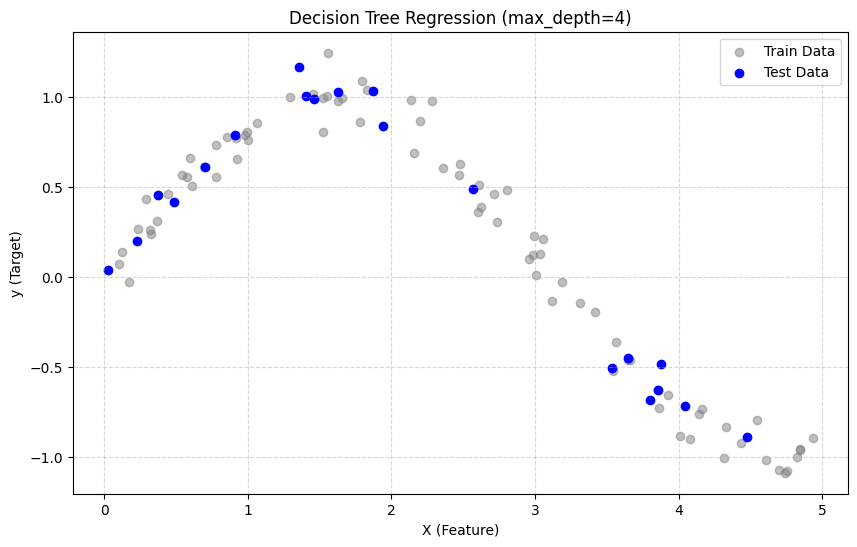

In [32]:
plt.figure(figsize=(10, 6))

# Plot training and testing points
plt.scatter(X_train, y_train, color='gray', alpha=0.5, label='Train Data')
plt.scatter(X_test, y_test, color='blue', label='Test Data')

# Plot the step-like prediction line
#plt.plot(X_grid, y_grid_pred, color='red', linewidth=2, label='Decision Tree Predictions')

plt.title('Decision Tree Regression (max_depth=4)')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()